## Machine Learning for Hyperspectral Image Analysis
### Sagar Lekhak, Phd Student, Year II.
### Chester F. Carlson Center for Imaging Science, Rochester Institute of Technology.

#

In [69]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spectral as spy
import spectral.io.envi as envi
from IPython.core.pylabtools import figsize



## Problem 1: Display Hyperspectral Image and Correlation Matrix

### Problem 1a: Load the hyperspectral image data (tait_hsi.hdr), display the R, G, B bands and pseudo NIR_R_G image.

In [2]:
tait_data = envi.open('tait_hsi.hdr','tait_hsi')  #function to open HSI files and automatically handles .hdr files
#We can omit the second argument 'tait_hsi' if the .hdr file has the same name as the .dat file or .img file
#we can also open the data using spy.open_image and then use img.load() to load the data. It is shown later in the code.

In [3]:
tait_data

	Data Source:   '.\tait_hsi'
	# Rows:           1039
	# Samples:        1087
	# Bands:           273
	Interleave:        BSQ
	Quantization:  32 bits
	Data format:   float32

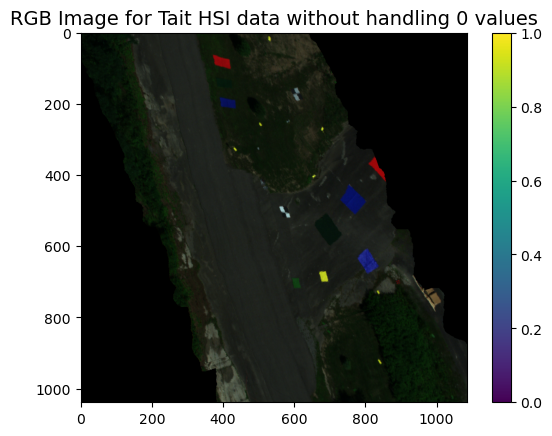

In [4]:
#Select blue, green, and red bands
blue_band = tait_data[:,:,24] # 451.996 nm
green_band = tait_data[:,:,68] # 549.939 nm
red_band = tait_data[:,:,113] # 650.109 nm
nir_band = tait_data[:,:,203] # 850.447 nm

rgb_image = np.dstack((red_band, green_band, blue_band))

#normalize for display
rgb_image = (rgb_image - np.min(rgb_image)) / (np.max(rgb_image) - np.min(rgb_image))

#display image
plt.imshow(rgb_image)
plt.colorbar()
plt.title('RGB Image for Tait HSI data without handling 0 values',fontsize = 14)
plt.show()

The resulted image is due to presence of large number of 0 or no data point values. It is very difficult to see the image because of the presence of zero values. Let's check such values and replace the zero values with NaN and display the image again.

In [5]:
# Check minimum and maximum pixel values
hsi_data = spy.open_image('tait_hsi.hdr')  #we can also open the data using spy.open_image and then use img.load() to load the data. It requires .hdr file as an argument.
data = hsi_data.load()  #This method reads the pixel values from the data file and stores them in a NumPy array

print("Min pixel value:", np.min(data))
print("Max pixel value:", np.max(data))

# Count zero pixels
print("Number of zero pixels:", np.sum(data == 0))

Min pixel value: 0.0
Max pixel value: 1418.0


C:\Users\Usuario\AppData\Local\Temp\ipykernel_332\1493535434.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print("Number of zero pixels:", np.sum(data == 0))


Number of zero pixels: 109614316


In [6]:
# Load image
tait_data1 = spy.envi.open('tait_hsi.hdr', 'tait_hsi')  #function to open HSI files and automatically handles .hdr files
img = tait_data1.load()  #This method reads the pixel values from the data file and stores them in a NumPy array with r x c x bands dimensions

#1. For RGB image:
# Define RGB bands
rgb_bands = [113, 68, 24]  # Be careful with the band indices order. It results in different colors if not in the correct order. Eg. [24, 68, 113]

# Convert zeros to NaN
img = np.where(img == 0, np.nan, img)

# Extract RGB bands
rgb_img = img[:, :, rgb_bands]

# Normalize while ignoring NaN
rgb_img = (rgb_img - np.nanmin(rgb_img)) / (np.nanmax(rgb_img) - np.nanmin(rgb_img))

#  Replace NaN with black (0) for display
rgb_img = np.nan_to_num(rgb_img)


C:\Users\Usuario\AppData\Local\Temp\ipykernel_332\920470149.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  img = np.where(img == 0, np.nan, img)


In [7]:
#2. Function for contrast stretching
def contrast_stretch(image, pmin=2, pmax=98):
    """Performs contrast stretching using percentile-based min-max scaling."""
    min_val = np.percentile(image, pmin)  # Compute 2nd percentile
    max_val = np.percentile(image, pmax)  # Compute 98th percentile

    stretched = (image- min_val) / (max_val - min_val)  # Normalize
    stretched = np.clip(stretched, 0, 1)  # Clip values to [0,1] range

    return stretched

#Apply contrast stretching to RGB bands
stretched_img = contrast_stretch(rgb_img)

In [8]:
#3. For NIR-R-G image:
# Define NIR_RG bands
nir_rg_bands = [203, 113, 68]  # Again, be careful with the band indices order. It results in different colors if not in the correct order. Eg. [68, 113, 203]

# Extract RGB bands
nir_img = img[:, :, nir_rg_bands]

# Normalize while ignoring NaN
nir_img = (nir_img - np.nanmin(nir_img)) / (np.nanmax(nir_img) - np.nanmin(nir_img))

# Replace NaN with black (0) for display
nir_img = np.nan_to_num(nir_img)

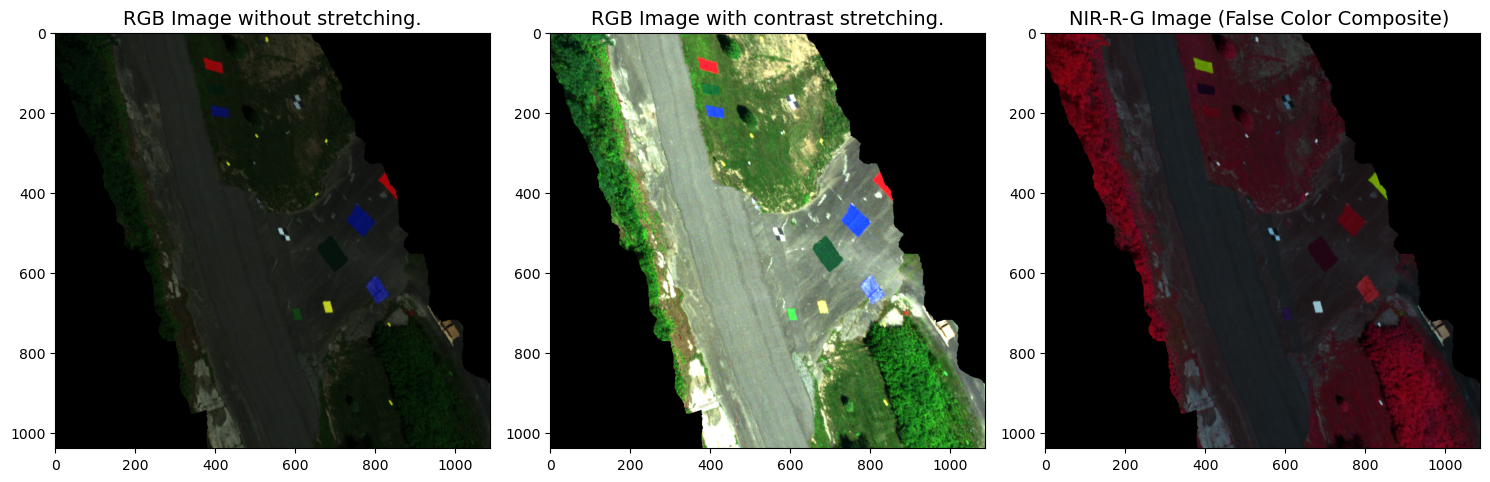

In [9]:
#Display the RGB and pseudo NIR_R_G images.

fig, axes = plt.subplots(1, 3, figsize=(15, 8))

# Display RGB image
axes[0].imshow(rgb_img)
axes[0].set_title("RGB Image without stretching.", fontsize=14)

# Display RGB image with contrast stretching
axes[1].imshow(stretched_img)
axes[1].set_title("RGB Image with contrast stretching.", fontsize=14)

# Display NIR-R-G image (pseudo-color image or also called false color composite image.)
axes[2].imshow(nir_img)
axes[2].set_title("NIR-R-G Image (False Color Composite) ", fontsize=14)

plt.tight_layout()
plt.show()


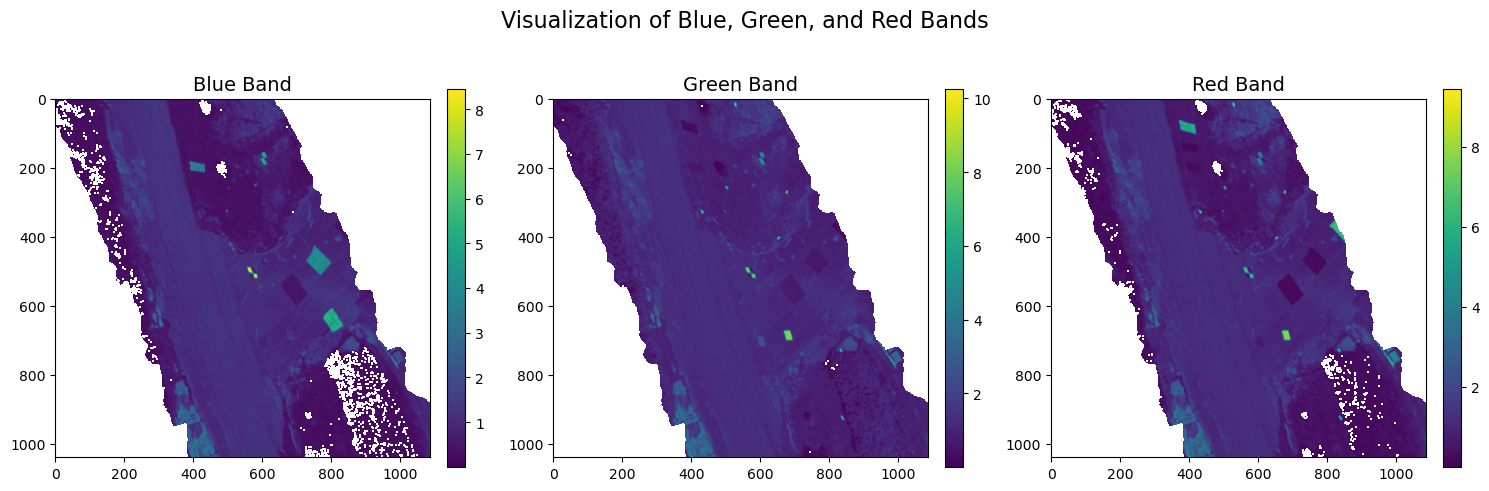

In [10]:

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Add a supertitle for the entire figure
plt.suptitle("Visualization of Blue, Green, and Red Bands", fontsize=16, y=1)

# Display blue, green, and red bands
im0 = axes[0].imshow(img[:, :, 24])  # Store the return value of imshow
axes[0].set_title("Blue Band", fontsize=14)
plt.colorbar(im0, ax=axes[0],orientation='vertical', fraction=0.046, pad=0.04)  # Add colorbar to the first subplot

im1 = axes[1].imshow(img[:, :, 68])
axes[1].set_title("Green Band", fontsize=14)
plt.colorbar(im1, ax=axes[1], orientation='vertical', fraction=0.046, pad=0.04)

im2 = axes[2].imshow(img[:, :, 113])
axes[2].set_title("Red Band", fontsize=14)
plt.colorbar(im2, ax=axes[2], orientation='vertical', fraction=0.046, pad=0.04)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

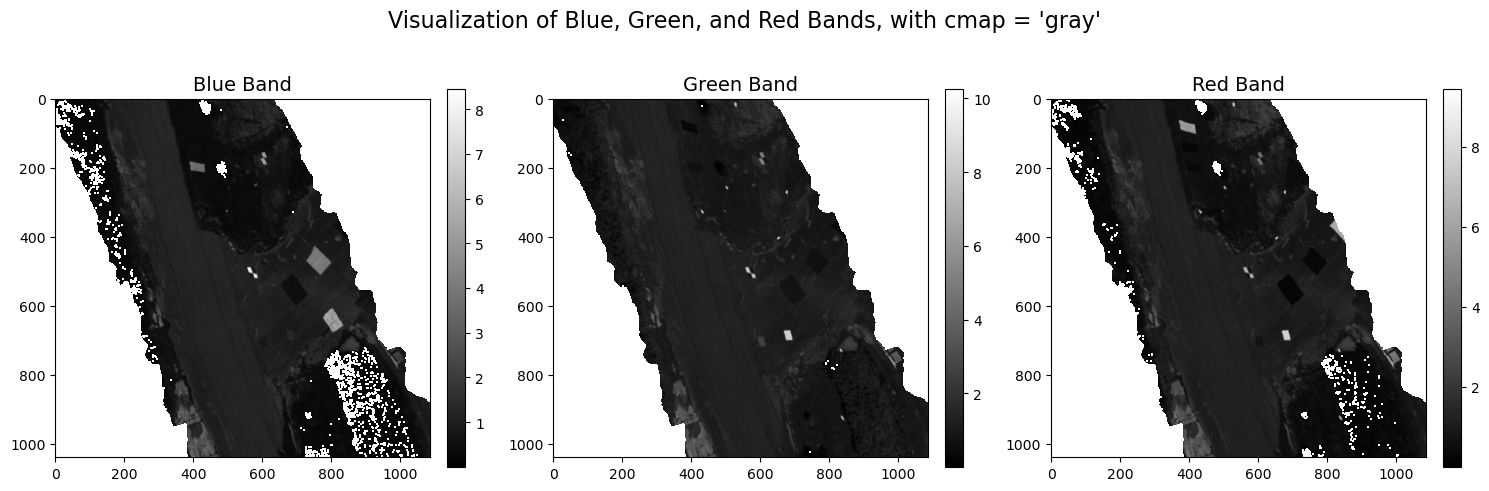

In [11]:

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Add a supertitle for the entire figure
plt.suptitle("Visualization of Blue, Green, and Red Bands, with cmap = 'gray'", fontsize=16, y=1)

# Display blue, green, and red bands
im0 = axes[0].imshow(img[:, :, 24], cmap = 'gray')  # Store the return value of imshow
axes[0].set_title("Blue Band", fontsize=14)
plt.colorbar(im0, ax=axes[0],orientation='vertical', fraction=0.046, pad=0.04)  # Add colorbar to the first subplot

im1 = axes[1].imshow(img[:, :, 68], cmap = 'gray')
axes[1].set_title("Green Band", fontsize=14)
plt.colorbar(im1, ax=axes[1], orientation='vertical', fraction=0.046, pad=0.04)

im2 = axes[2].imshow(img[:, :, 113], cmap = 'gray')
axes[2].set_title("Red Band", fontsize=14)
plt.colorbar(im2, ax=axes[2], orientation='vertical', fraction=0.046, pad=0.04)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

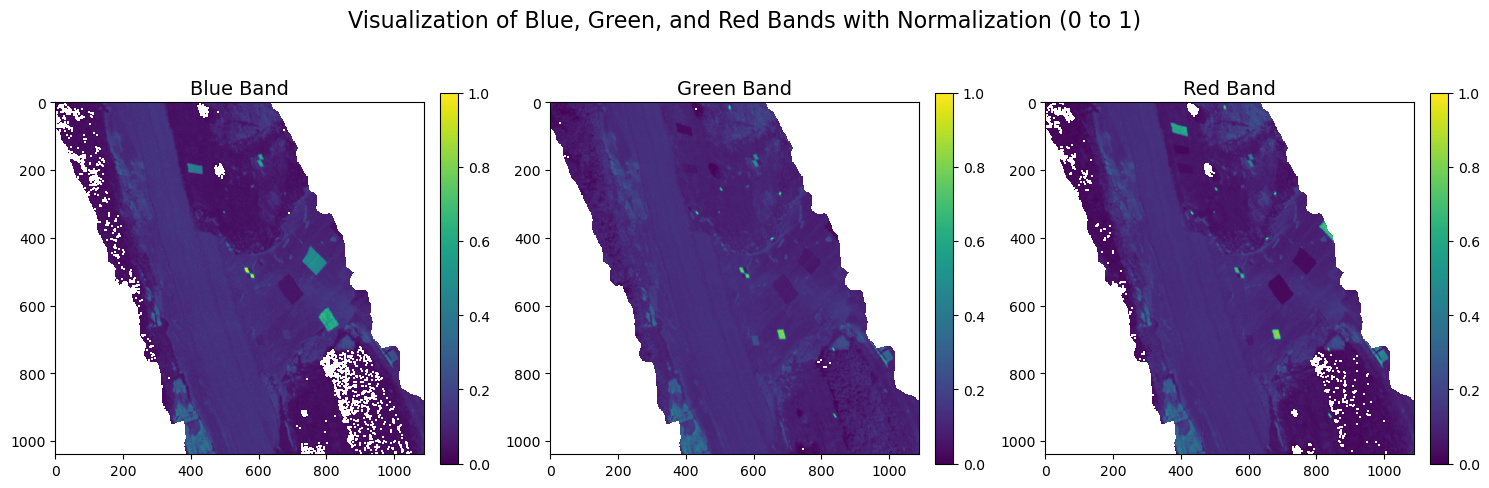

In [12]:
#Display these bands with normalization.
# Extract the bands
blue_band = img[:, :, 24]
green_band = img[:, :, 68]
red_band = img[:, :, 113]

# Normalize each band to [0, 1]
blue_band_normalized = (blue_band - np.nanmin(blue_band)) / (np.nanmax(blue_band) - np.nanmin(blue_band))
green_band_normalized = (green_band - np.nanmin(green_band)) / (np.nanmax(green_band) - np.nanmin(green_band))
red_band_normalized = (red_band - np.nanmin(red_band)) / (np.nanmax(red_band) - np.nanmin(red_band))

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # Adjust figsize for better layout

# Add a supertitle for the entire figure
plt.suptitle("Visualization of Blue, Green, and Red Bands with Normalization (0 to 1)", fontsize=16, y=1)

# Display blue, green, and red bands with colorbars
im0 = axes[0].imshow(blue_band_normalized)  # Blue band
axes[0].set_title("Blue Band", fontsize=14)
plt.colorbar(im0, ax=axes[0], orientation='vertical', fraction=0.046, pad=0.04)  # Add colorbar

im1 = axes[1].imshow(green_band_normalized)  # Green band
axes[1].set_title("Green Band", fontsize=14)
plt.colorbar(im1, ax=axes[1], orientation='vertical', fraction=0.046, pad=0.04)  # Add colorbar

im2 = axes[2].imshow(red_band_normalized)  # Red band
axes[2].set_title("Red Band", fontsize=14)
plt.colorbar(im2, ax=axes[2], orientation='vertical', fraction=0.046, pad=0.04)  # Add colorbar

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

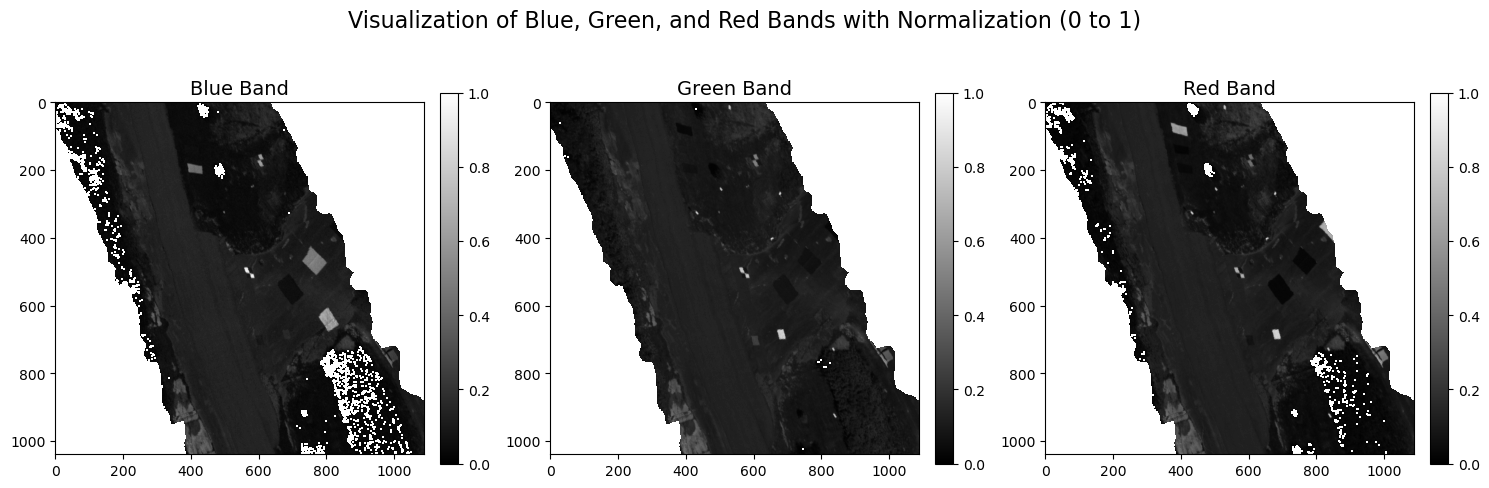

In [13]:
#Display these bands with normalization.
# Extract the bands
blue_band = img[:, :, 24]
green_band = img[:, :, 68]
red_band = img[:, :, 113]

# Normalize each band to [0, 1]
blue_band_normalized = (blue_band - np.nanmin(blue_band)) / (np.nanmax(blue_band) - np.nanmin(blue_band))
green_band_normalized = (green_band - np.nanmin(green_band)) / (np.nanmax(green_band) - np.nanmin(green_band))
red_band_normalized = (red_band - np.nanmin(red_band)) / (np.nanmax(red_band) - np.nanmin(red_band))

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # Adjust figsize for better layout

# Add a supertitle for the entire figure
plt.suptitle("Visualization of Blue, Green, and Red Bands with Normalization (0 to 1)", fontsize=16, y=1)

# Display blue, green, and red bands with colorbars
im0 = axes[0].imshow(blue_band_normalized, cmap = 'gray')  # Blue band
axes[0].set_title("Blue Band", fontsize=14)
plt.colorbar(im0, ax=axes[0], orientation='vertical', fraction=0.046, pad=0.04)  # Add colorbar

im1 = axes[1].imshow(green_band_normalized, cmap = 'gray')  # Green band
axes[1].set_title("Green Band", fontsize=14)
plt.colorbar(im1, ax=axes[1], orientation='vertical', fraction=0.046, pad=0.04)  # Add colorbar

im2 = axes[2].imshow(red_band_normalized, cmap = 'gray')  # Red band
axes[2].set_title("Red Band", fontsize=14)
plt.colorbar(im2, ax=axes[2], orientation='vertical', fraction=0.046, pad=0.04)  # Add colorbar

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

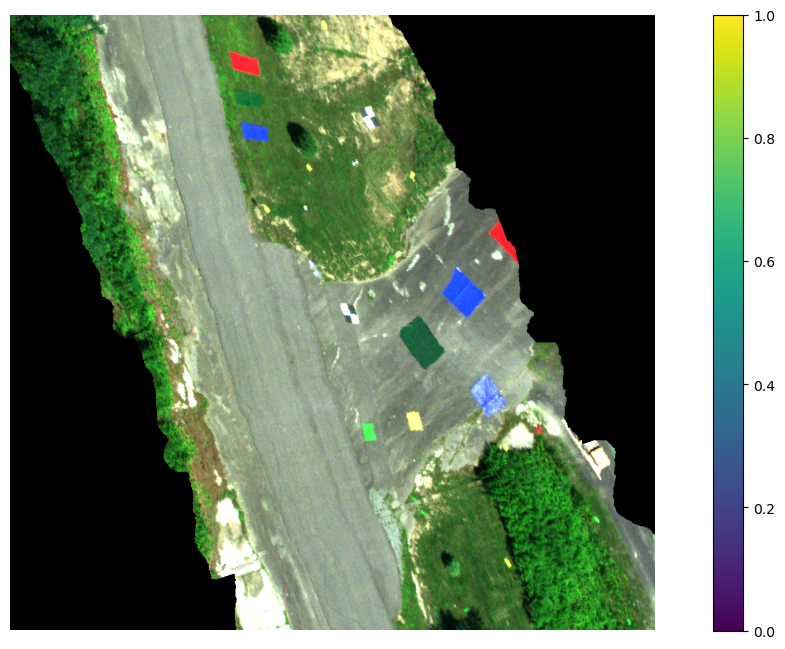

In [14]:
#Zoom the pseudo NIR_R_G image.
plt.figure(figsize=(15, 8))
plt.imshow(stretched_img)
plt.colorbar()
plt.axis("off")
plt.show()

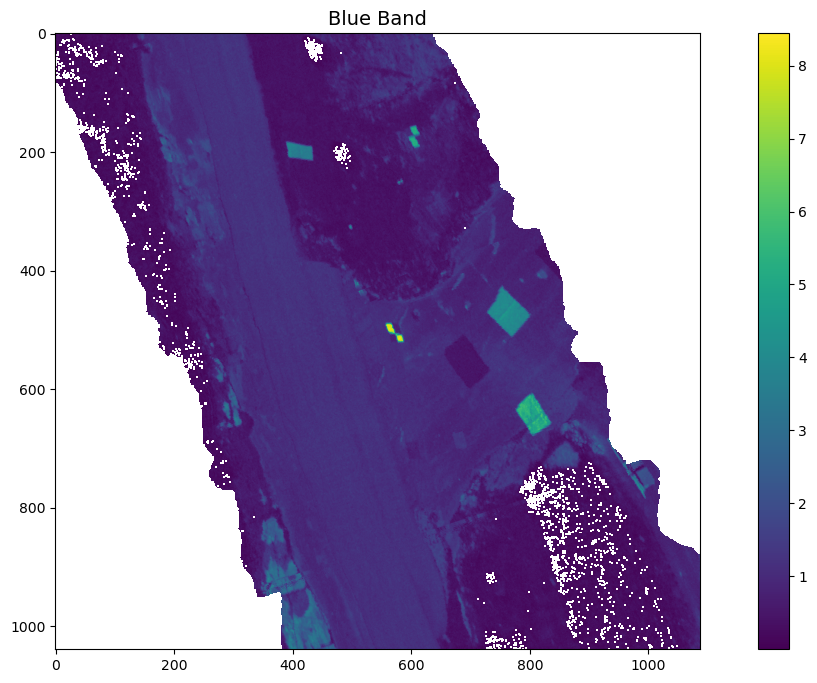

In [15]:
#Zoom the blue band

plt.figure(figsize=(15, 8))

plt.imshow(img[:,:,24])
plt.colorbar()
plt.title('Blue Band',fontsize = 14)
plt.show()

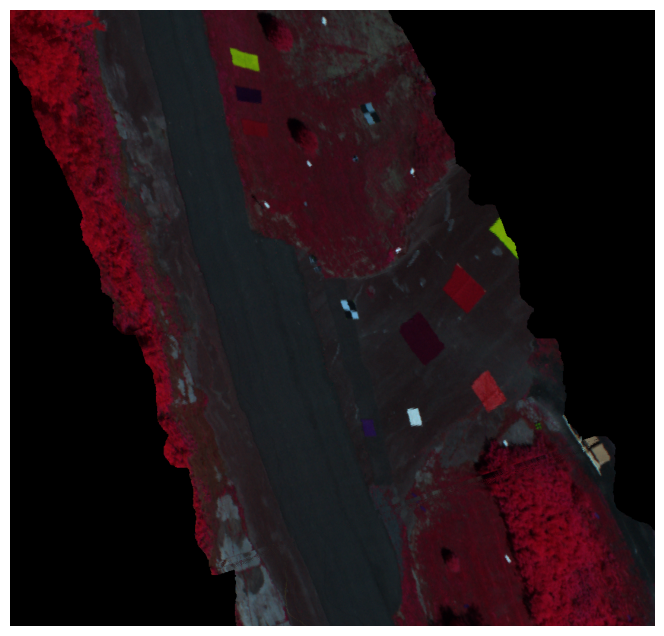

In [16]:
#Zoom the pseudo NIR_R_G image.
plt.figure(figsize=(15, 8))

plt.imshow(nir_img)
#plt.colorbar()
plt.axis("off")
plt.show()


### **Comments on Problem 1.a:**

#### **Analysis of Hyperspectral Dataset**

The provided hyperspectral dataset has dimensions of **1039 × 1087 × 273** (rows × columns (samples) × bands). The dataset was loaded and processed using various methods from the **Spectral Python (SPy) library** and the **ENVI module**. A large number of **no-data** or **zero** values were present, leading to improper visualization in RGB imagery. To address this, no-data points were replaced using the **NaN function in NumPy**. Afterward, **contrast stretching** was applied to enhance the image's visualization. The RGB composite image revealed several **large panels of different colors** within the scene.

#### **Band-wise Analysis**

#### **Blue Band**
- **Vegetation absorbed most blue light** due to the presence of chlorophyll and reflects less compared to the green or near-infrared region.
- **Blue panels exhibited high reflectance**, while shadows of trees and vegetation had **very low reflectance** or were treated as no-data points (0 values).
- **White surfaces, such as Ground Control Points (GCPs), showed high reflectance** compared to other regions in the scene.
- **Blue objects reflected blue light strongly** while absorbing other wavelengths, making them appear **bright**.

#### **Green Band**
- **Yellow and white objects displayed higher reflectance**, while shadows showed moderate reflectance—not as low as in the blue band.
- This could be due to **scattering of green light** in the atmosphere or **reflected green light from surrounding surfaces**.
- Although vegetation is green and expected to show **high reflectance in the green band**, only **moderate reflectance** was observed, primarily due to **chlorophyll absorption**.

#### **Red Band**
- **Red objects exhibited high reflectance**, while **white objects strongly reflected red light**.
- **Vegetation absorbed most red light**, but **not as significantly** as in the blue band.
- Among the three bands, **green light was absorbed the least** by vegetation.

#### **Interesting Observations in R, G, B bands.**
- **Yellow objects showed higher reflectance in both the green and red bands**, indicating that they reflect both **red and green light** while **absorbing blue light**.
- **Similarities across all bands:**
  1. **White objects exhibited high reflectance.**
  2. **Vegetation showed moderate reflectance** due to **chlorophyll absorption**.

#### **False Color Composite Analysis (NIR-R-G)**

In NIR_R_G image or false color composite, NIR is assigned as red, red as green and green as blue channel. After creating a **false color composite** of the **NIR-R-G bands**, we observed that **vegetation** and **red panels** were represented by **dark red**. This implies that vegetation reflects **near-infrared (NIR)** and **green light** while absorbing **red light**. Vegetation reflects more **NIR light** than **green light**, which is why it appears as **deep red** or **bright red** in the composite. This characteristic helps estimate **plant health** and **density**, as **less dense** or **unhealthy vegetation** appears as **light red** or **dull red**.

However, this visualization can sometimes be confusing because **blue panels** also tend to appear similar to **bright red** in the scene. Although blue objects show low reflectance in all false composite bands, but sometimes due to material properties, they may appear red, which can be confused as vegetation. Additionally:
- **Yellow objects** appear as **white** in the composite.
- **Red objects** appear as **light green**.
- **Shadows** appear as **dark regions**.
- **Green objects** appear as **red** or **dark red**.

---

#### **Important Info**
- **Vegetation Health**: The **bright red** color of vegetation in the NIR-R-G composite indicates **healthy vegetation** due to high NIR reflectance. **Unhealthy vegetation** appears as **dull red** or **light red** because of reduced NIR reflectance.
- **Confusing Elements**:
  - **Blue panels** may appear similar to **bright red**, which can lead to misinterpretation.
  - **Yellow objects** appear **white**, and **red objects** appear **light green**, adding complexity to the interpretation.
- **Shadows**: Shadows appear as **dark regions** in the composite, as they reflect little NIR, red, or green light.

---

#### **Conclusion**
The **NIR-R-G false color composite** can be used as a powerful tool for analyzing vegetation health and density. However, care must be taken to distinguish between **vegetation** and other objects (e.g., sometimes blue panels due to material properties) that may appear similar in the composite. Understanding the reflectance properties of different materials in the NIR, red, and green bands is crucial for accurate interpretation.




### Problem 1.b: Compute and display correlation matrix as an image and analyze correlation between spectral bands.

In [17]:
# Calculating correlation matrix and displaying it like HW1 results in error: AttributeError: module 'matplotlib.cm' has no attribute 'register_cmap'. The error is while displaying a heat map using sns.heatmap(correlation_matrix) function. Discrepancies may be in matplotlib version or sns. Also, it took a long time and couldn't compute until 12 minutes using approach as in HW1. So, the following approach is applied.

In [70]:
def calculate_correlation_matrix(hyperspectral_data):
    """
    Calculates the correlation matrix for hyperspectral data.

    Args:
        hyperspectral_data (numpy.ndarray): A 3D numpy array representing the hyperspectral data,
                                             where dimensions are (height, width, bands).

    Returns:
        pandas.DataFrame: A DataFrame representing the correlation matrix between spectral bands.
    """

    num_bands = hyperspectral_data.shape[2]
    reshaped_data = hyperspectral_data.reshape(-1, num_bands) # Reshape to (pixels, bands)

    df = pd.DataFrame(reshaped_data)
    correlation_matrix = df.corr()
    return correlation_matrix

In [26]:
calculate_correlation_matrix(img)

,0,1,2,3,4,5,6,7,8,9,...,263,264,265,266,267,268,269,270,271,272
0,1.000000,0.517263,0.555573,0.573246,0.588861,0.595178,0.603253,0.611250,0.616555,0.615175,...,-0.217316,-0.211577,-0.216831,-0.210145,-0.212646,-0.206079,-0.212559,-0.205315,-0.209182,0.045145
1,0.517263,1.000000,0.657597,0.680424,0.693273,0.712638,0.717949,0.728741,0.730788,0.737424,...,-0.260134,-0.255509,-0.259699,-0.252347,-0.255658,-0.249893,-0.254434,-0.248058,-0.250041,0.065271
2,0.555573,0.657597,1.000000,0.730926,0.751531,0.764918,0.778182,0.785145,0.792513,0.794395,...,-0.287511,-0.279877,-0.285102,-0.277443,-0.281012,-0.272175,-0.279602,-0.271374,-0.275773,0.060957
3,0.573246,0.680424,0.730926,1.000000,0.780714,0.796347,0.804203,0.820263,0.823051,0.827808,...,-0.301412,-0.293114,-0.298550,-0.289904,-0.293169,-0.286659,-0.293957,-0.284944,-0.288873,0.059294
4,0.588861,0.693273,0.751531,0.780714,1.000000,0.815715,0.829151,0.840928,0.848999,0.849195,...,-0.303650,-0.294199,-0.300396,-0.291446,-0.295292,-0.287290,-0.295220,-0.285854,-0.289932,0.056051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,-0.206079,-0.249893,-0.272175,-0.286659,-0.287290,-0.295188,-0.290380,-0.298093,-0.297667,-0.303825,...,0.797537,0.800603,0.794496,0.796746,0.789919,1.000000,0.777854,0.777416,0.767560,-0.061438
269,-0.212559,-0.254434,-0.279602,-0.293957,-0.295220,-0.303575,-0.298394,-0.306694,-0.306042,-0.311782,...,0.792451,0.788256,0.791994,0.786508,0.782670,0.777854,1.000000,0.769105,0.762299,-0.072406
270,-0.205315,-0.248058,-0.271374,-0.284944,-0.285854,-0.294211,-0.288804,-0.296142,-0.296472,-0.302393,...,0.785743,0.788532,0.783625,0.787308,0.776612,0.777416,0.769105,1.000000,0.756695,-0.061803
271,-0.209182,-0.250041,-0.275773,-0.288873,-0.289932,-0.298701,-0.294672,-0.300819,-0.300604,-0.306645,...,0.781719,0.776878,0.778586,0.773113,0.772965,0.767560,0.762299,0.756695,1.000000,-0.072159


In [22]:
correlation_matrix = calculate_correlation_matrix(img)

In [44]:
def visualize_heatmap(correlation_matrix, cmap='coolwarm', figsize=(10, 8), annotate=True):
    """
    Visualizes a correlation matrix as a heatmap using Matplotlib.

    Args:
        correlation_matrix (pandas.DataFrame): The correlation matrix to visualize.
        cmap (str): Colormap to use for the heatmap (default: 'coolwarm').
        figsize (tuple): Size of the figure (default: (10, 8)).
        annotate (bool): Whether to display correlation coefficients on the heatmap (default: True).
    """
    # Convert the correlation matrix to a NumPy array
    corr_values = correlation_matrix.values

    # Create the heatmap using Matplotlib
    plt.figure(figsize=figsize)
    plt.imshow(corr_values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

    # Add a colorbar
    cbar = plt.colorbar(shrink=0.8)
    cbar.set_label("Correlation Coefficient (r)")

    # Set title and labels
    plt.title("Correlation Matrix Heatmap", fontsize=16)
    plt.xlabel("Bands", fontsize=14)
    plt.ylabel("Bands", fontsize=14)

    # # Set tick labels
    # band_labels = correlation_matrix.columns
    # plt.xticks(range(len(band_labels)), band_labels, rotation=45)
    # plt.yticks(range(len(band_labels)), band_labels, rotation=0)
    #
    # # Display correlation coefficients on the heatmap (if annotate=True)
    # if annotate:
    #     for i in range(len(band_labels)):
    #         for j in range(len(band_labels)):
    #             plt.text(j, i, f"{corr_values[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8)

    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()

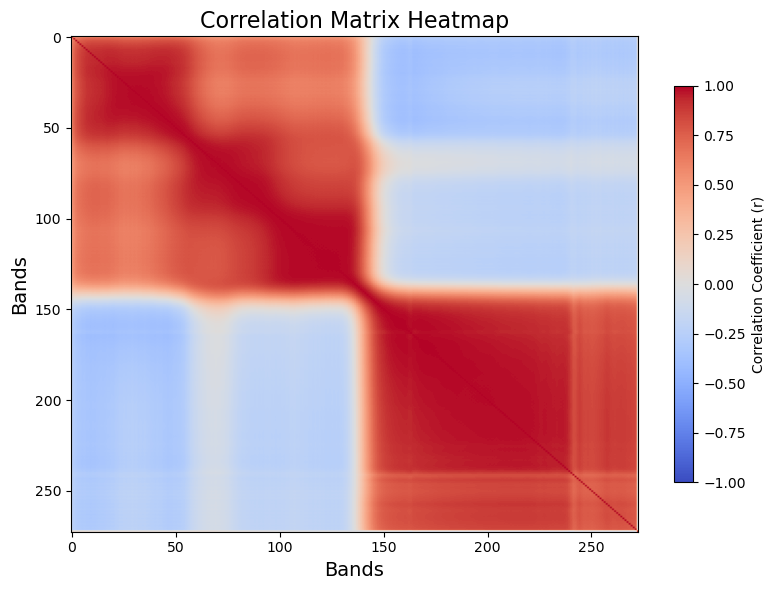

In [47]:
# Visualize the heatmap
visualize_heatmap(
    correlation_matrix,
    cmap='coolwarm',  # Use a coolwarm colormap
    figsize=(8, 6),   # Set figure size
    annotate=False     # Display correlation coefficients
)

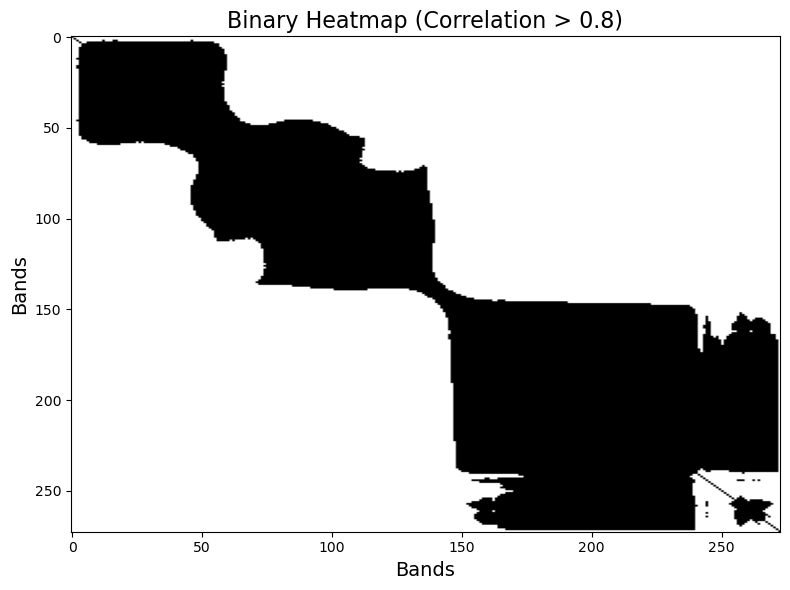

In [48]:
# Set a correlation threshold
threshold = 0.8
num_bands = 273

# Create a binary heatmap
binary_heatmap = (correlation_matrix > threshold).astype(int)

# Plot the binary heatmap
plt.figure(figsize=(8, 6))
plt.imshow(binary_heatmap, cmap='binary', aspect='auto')

# Add labels
plt.title(f"Binary Heatmap (Correlation > {threshold})", fontsize=16)
plt.xlabel("Bands", fontsize=14)
plt.ylabel("Bands", fontsize=14)

# # Set tick labels
# band_labels = [f"Band {i+10}" for i in range(num_bands)]
# plt.xticks(range(num_bands), band_labels, rotation=90)
# plt.yticks(range(num_bands), band_labels)

plt.tight_layout()
plt.show()

In [68]:
#Interactive heatmap
import plotly.express as px

band_labels = correlation_matrix.columns

# Create an interactive heatmap
fig2 = px.imshow(
    correlation_matrix,
    labels=dict(x="Band Index", y="Band Index", color="Correlation"),
    x=band_labels,
    y=band_labels,
    color_continuous_scale='RdBu',
    zmin=-1,
    zmax=1,
)

# Add hover information
fig2.update_traces(
    hovertemplate="Band %{x}: %{y}<br>Correlation: %{z:.2f}<extra></extra>"
)

# Add a title to the heatmap
fig2.update_layout(
    title="Interactive Stretching of Correlation Matrix of Tait Hyperspectral Data Bands",
    title_x=0.5,  # Center the title
    title_font=dict(size=20)  # Adjust title font size
)

# Show the plot
fig2.show()

### **Comments on Problem 1.b:**




### Problem 2 : Principal Component Analysis (PCA)

#### (2.a)(10 points) Write a function that takes an array of size m×d, (where m is the number of samples and d is the number of features). Your function should return 1) all principal components as an array, 2) eigenvalues, and 3) standardized data.
 Note:
 - In this case, mean-centering your data prior to passing to SVD should be enough, as
 the data is of a certain bit and in physical units. But keep in mind, for features across
 different units and scales, you will need to perform standardization (mean-centering +
 dividing by standard deviation) as each features can have different range of values and
 scales.
 - Mean-centering should be done on each feature separately.
 - Do not use a libary for PCA calculation, you may use a library for SVD calculation.
 - Make sure the eigenvalues and corr. eigenvectors are sorted
 - Provide sufficient explanation in your code
 - pcs, eigenvalues, mean_arr = principal_component_analysis(array)

Notes:
PCA is a specific application of SVD that focuses on variance maximization, while SVD is a general matrix decomposition technique that is widely used in many fields beyond PCA.

PCA and SVD, both are dimension reduction techniques used for data analysis.
PCA requires computing the covariance matrix and then performing eigen decomposition, which can be computationally expensive for large datasets. SVD on a mean-centered matrix essentially performs PCA without explicitly computing the covariance matrix. This method is often preferred for numerical stability and efficiency in large datasets.
SVD: Directly factorizes the original data matrix, often faster for large datasets.

In [61]:
#define a function
def principal_component_analysis(array):
    """
    Computes PCA using SVD for a given dataset.

    Parameters:
    array (numpy.ndarray): Input data of shape (m, d), where:
        - m is the number of samples
        - d is the number of features

    In our case or for HSI, Eg: if  hyperspectral data has dimensions (100 × 100 × 200) (Height × Width × Bands):
    Reshaped into (10000 × 200) → 10000 samples (pixels), 200 spectral bands (features).
    Here, each row is a pixel's spectral signature, and each column is a spectral band.
    So, after reshaping, each row is a sample and all columns (representing each band) are features.

    Returns:
    pcs (numpy.ndarray): Principal components (eigenvectors), shape (d, d)
    eigenvalues (numpy.ndarray): Eigenvalues corresponding to the principal components, shape (d,)
    mean_arr (numpy.ndarray): Mean of each feature before centering, shape (d,)
    """

    #Note: The following steps are same as extracting each band and doing following operations. Since we were asked to define a function that takes input as 2D data, so we are doing this.

    # Replace NaN with column mean
    array = np.nan_to_num(array, nan=np.nanmean(array)) # This is to handle nan values in the array. If it's not done, since we have nan values in our data, it results in error " SVD didn't converge " while calling this function.

    # Step 1: Compute the mean of each feature (column-wise mean) i.e., each band
    mean_arr = np.mean(array, axis=0)

    # Step 2: Mean-center the data (subtract feature-wise mean)
    mean_centered = array - mean_arr  #as mentioned in the question, we are also doing mean centering for standardization since all the features have same unit. If different features have different units, we would have to divide the mean centered data by standard deviation as well.

    # Step 3: Perform Singular Value Decomposition (SVD)
    U, S, Vt = np.linalg.svd(mean_centered, full_matrices=False)

    # Step 4: Compute eigenvalues (squared singular values divided by (m-1))
    eigenvalues = (S ** 2) / (array.shape[0] - 1)  # EigenValues correspond to variance

    ## In Step 4: using array.shape[0] affects the eigen value calculation because we have replaced the nan values by mean of the data, so there are more points whcih increases the size of array.shape[0].

    # Step 5: Extract principal components (columns of V)
    pcs = Vt.T  # Transpose to get principal components as columns

    # Step 6: Sort eigenvalues and corresponding eigenvectors in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]  # Indices for sorting in descending order
    eigenvalues = eigenvalues[sorted_indices]  # Sort eigenvalues
    pcs = pcs[:, sorted_indices]  # Sort principal components accordingly

    return pcs, eigenvalues, mean_centered


In [62]:
#Let's compute the principal components for our data. First, we need to reshape our 3D data to 2D.

img_reshaped =  img.reshape(-1, img.shape[2]) #reshapes to (r x c) x bands
pcs, eigenvalues, mean_arr = principal_component_analysis(img_reshaped)

# img_reshaped: Reshapes the hyperspectral image from (Height, Width, Bands) → (Pixels, Bands).
# pcs: The principal components (eigenvectors) → shape (Bands × Bands).
# eigenvalues: The variance explained by each principal component → shape (Bands,).
# mean_arr:  principal_component_analysis returns standardized data (mean-centered data in our case).

#For HSI data with 273 bands, the principal components (eigenvectors) will be a 273×273 matrix, the eigenvalues will be a vector of length 273, and the third return value, mean_arr, represents the mean-centered data (not just the mean itself).

print("Principal Components:\n", pcs)
print("Eigenvalues:\n", eigenvalues)
print("Mean of Features:\n", mean_arr)


Principal Components:
 [[ 3.6543007e-03  5.8230884e-02  1.0220116e-02 ...  2.7196760e-05
  -3.1656786e-05  4.8651364e-05]
 [ 3.7117680e-03  5.9099369e-02  1.7901268e-02 ...  5.0098020e-05
   7.5677344e-05 -7.8511963e-05]
 [ 3.6870083e-03  6.0226358e-02  2.5166368e-02 ...  4.3299799e-05
  -2.0198962e-04  5.6270260e-06]
 ...
 [ 2.7885444e-03  5.7459239e-02 -5.4270197e-02 ...  2.5087484e-04
   7.8584844e-06  3.2626809e-05]
 [ 2.8321447e-03  5.6135941e-02 -4.8857924e-02 ...  5.1561754e-05
   2.4051894e-04  1.3660877e-04]
 [-9.9856901e-01  5.2926548e-02  6.9824629e-03 ...  4.9066438e-07
   5.3416653e-07  4.0523896e-06]]
Eigenvalues:
 [2.49477375e+05 1.25300255e+02 5.05597687e+01 5.22736502e+00
 1.83438230e+00 1.26127195e+00 8.98598492e-01 7.56952941e-01
 5.47507703e-01 4.89360482e-01 4.02563065e-01 3.88932616e-01
 3.47557425e-01 3.06669921e-01 2.64228076e-01 2.36875042e-01
 2.23260030e-01 2.01481238e-01 1.94847897e-01 1.89087093e-01
 1.75474405e-01 1.71507329e-01 1.64121598e-01 1.62466720e-

In [63]:
pcs.shape

(273, 273)

In [64]:
eigenvalues.shape

(273,)

In [65]:
mean_arr.shape


(1129393, 273)

#### Pro(2.b)(10 points) Using PCA as a dimensionality reduction technique, apply PCA to the provided hyperspectral dataset. Extract the first 10 principal components, use them to transform your data into the lower dimension, reshape the the observation dimension to match the image dimensions, and plot them. Describe your observations—what patterns or features do you notice? Discuss what each principal component represents in the context of the hyperspectral data.

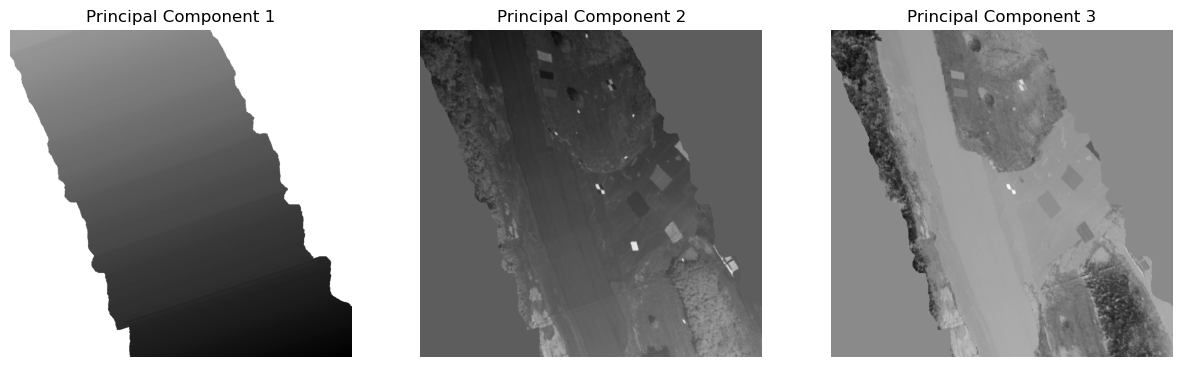

In [66]:
#
# Step 3: Project data onto the first 10 principal components
transformed_data = np.dot(mean_arr, pcs[:, :10])

# Step 4: Reshape the transformed data back to the image shape (r, c, 10)
transformed_img = transformed_data.reshape(img.shape[0], img.shape[1], 10)

# Step 5: Plot the first 3 principal components
fig3, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(3):  # Plot the first 3 components
    ax = axes[i]
    ax.imshow(transformed_img[:, :, i], cmap='gray')
    ax.set_title(f"Principal Component {i + 1}")
    ax.axis('off')

plt.show()

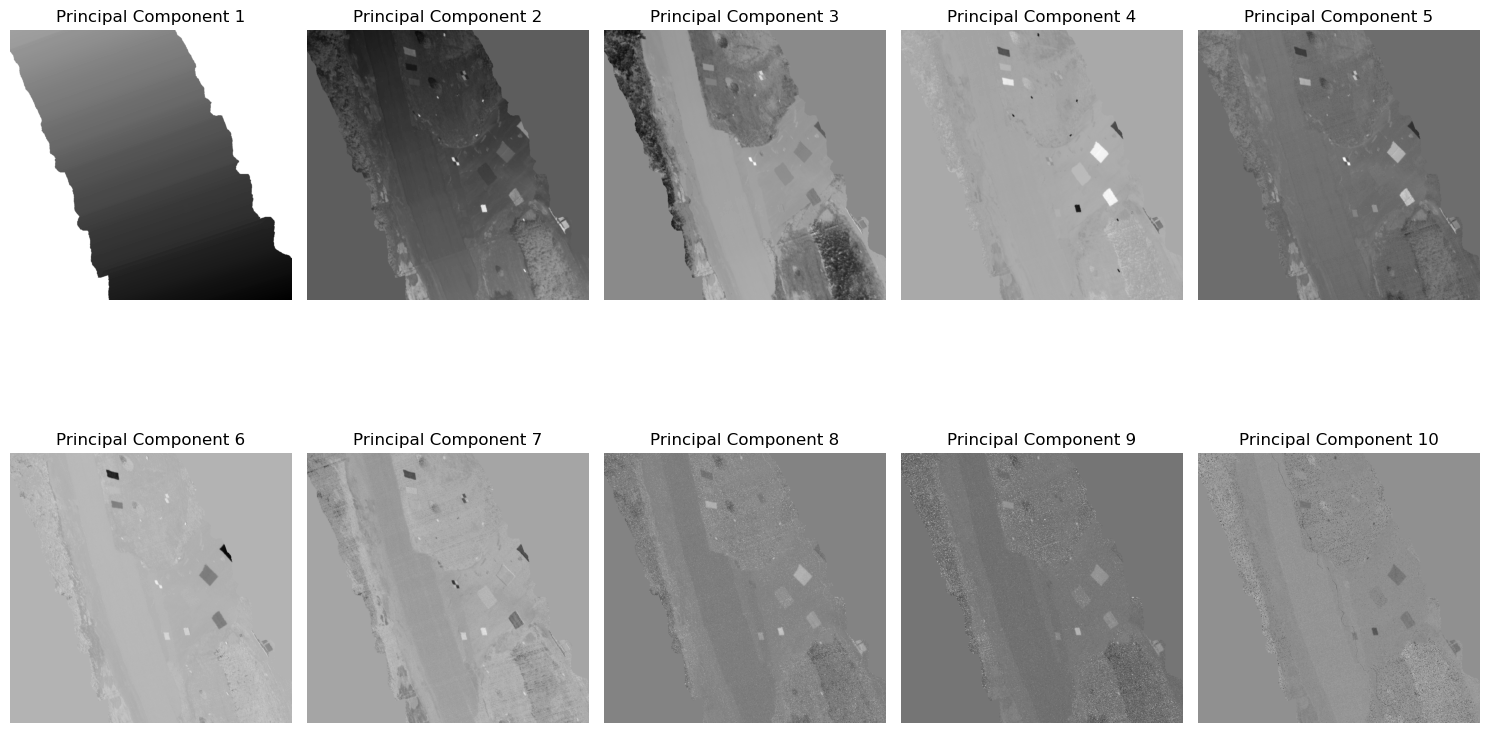

In [67]:

# Step 5: Plot the first 10 principal components
fig, axes = plt.subplots(2, 5, figsize=(15, 10))  # 2 rows, 5 columns for 10 PCs
axes = axes.ravel()  # Flatten the axes array to easily access each subplot

# Plot each of the first 10 principal components
for i in range(10):
    ax = axes[i]
    ax.imshow(transformed_img[:, :, i], cmap='gray')
    ax.set_title(f"Principal Component {i + 1}")
    ax.axis('off')

plt.tight_layout()
plt.show()